# Clinical Risk Prediction System

## Objective
Building a machine learning system that predicts probability of cardiovascular disease (binary classification) based on patient clinical features.

## Problem Statement
- Early prediction of heart disease is critical in healthcare. 
- Missing a positive case or false negative can have serious consequences.  
- This project focuses on building a predictive model with emphasis on recall and decision reliability.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


## Data Understanding

The dataset contains patient clinical attributes or data such as age, chest pain type, cholesterol levels, heart rate, etc.

### Key Points:
- Target variable: `target` ( kept as: 0 = no disease, 1 = disease)
- No missing values found
- Dataset is relatively balanced

In [31]:
# Loading the dataset
df = pd.read_csv("data/heart.csv")

# Basic info
df.head()
df.describe()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [32]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print((df == '?').sum())

Shape: (1025, 14)

Columns:
 Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


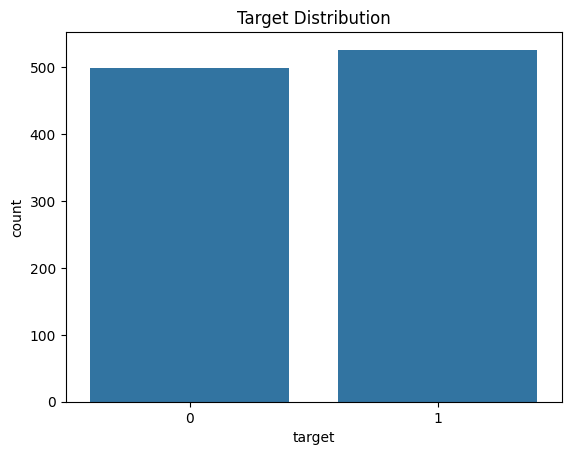

In [33]:
# Target distribution
df['target'].value_counts()
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

In [34]:
df['target'].value_counts(normalize=True) * 100



target
1    51.317073
0    48.682927
Name: proportion, dtype: float64

### Correlation Insights

- Correlation provides initial insights but does not imply causation which implies that model coefficients provide more reliable importance.
- Chest pain type (cp) and maximum heart rate (thalach) are moderately correlated features indicating potential predictive signals, aligning with known clinical indicators.They have strong positive correlation with heart disease.
- Whereas, features like exercise-induced angina (exang) shows negative correlation.
- These features are important indicators for prediction.

Correlation with Target:

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


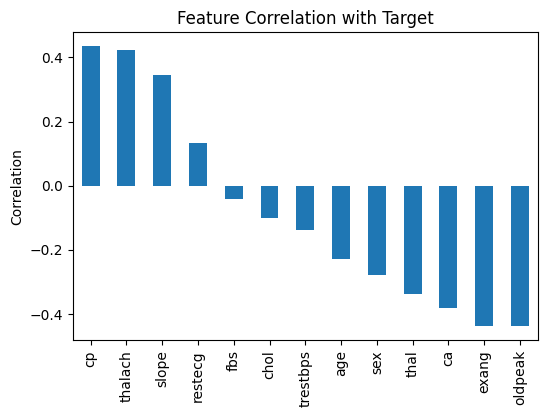

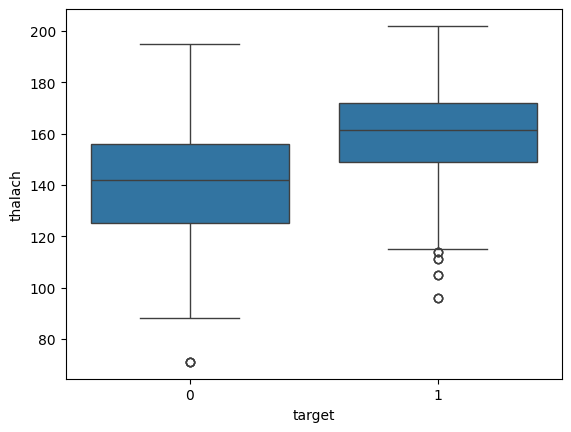

In [35]:
# Feature correlation with target
corr_target = df.corr()["target"].sort_values(ascending=False)
print("Correlation with Target:\n")
print(corr_target)
plt.figure(figsize=(6,4))
corr_target.drop("target").plot(kind='bar')
plt.title("Feature Correlation with Target")
plt.ylabel("Correlation")
plt.show()
sns.boxplot(x="target", y="thalach", data=df)
plt.show()

## Preprocessing

- Separated the features and target variable.
- Stratification of train-test split done to preserve class distribution.
- StandardScaler used to normalize feature values.
- Pipeline created to prevent data leakage.

## Model Training and Evaluation

Model performance evaluation done using:
- Classification Report (Precision, Recall, F1-score)
- ROC-AUC Score
- Confusion Matrix

ROC Curve is plotted to analyze model discrimination ability.

 Classification Report 
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205

ROC-AUC Score: 0.9306666666666668

 Confusion Matrix 
[[70 30]
 [ 9 96]]


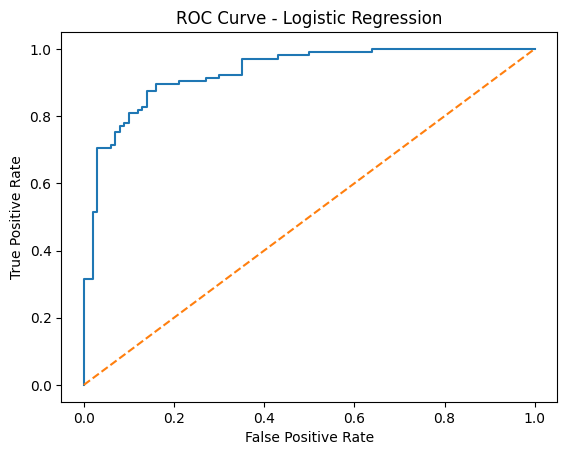

In [36]:
# PREPROCESSING + BASELINE MODEL

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Define Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# Stratified Train-Test Split (important for medical data)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1: Base pipeline 
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])


# Step 2: calibration
model = CalibratedClassifierCV(
    lr_pipeline,
    method='sigmoid',
    cv=5
)

# Step 3: Train
model.fit(X_train, y_train)


# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print(" Classification Report ")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("\n Confusion Matrix ")
print(confusion_matrix(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [37]:

from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(lr_pipeline, X, y, cv=5, scoring='roc_auc')
print("LR CV ROC-AUC:", lr_scores)
print("Mean:", lr_scores.mean())

LR CV ROC-AUC: [0.94780952 0.93533333 0.93066667 0.89085714 0.87411854]
Mean: 0.9157570421193062


## Manual Threshold Adjustment

A custom threshold (0.3) is applied instead of default 0.5 to:
- Increase recall
- Reduce false negatives (critical in medical diagnosis).

Threshold is lowered to prioritize recall because missing disease cases is more critical than false alarms.

## Threshold Selection Strategies

Two thresholding approaches were explored:

- A manual threshold (0.3) was chosen to prioritize recall and reduce false negatives, which is critical in medical diagnosis.
- An optimal threshold was computed using the F1-score to achieve a balanced trade-off between precision and recall.

This comparison highlights how threshold selection can be adapted based on clinical priorities.


 Custom Threshold (0.3) 
              precision    recall  f1-score   support

           0       0.95      0.62      0.75       100
           1       0.73      0.97      0.83       105

    accuracy                           0.80       205
   macro avg       0.84      0.80      0.79       205
weighted avg       0.84      0.80      0.79       205


Confusion Matrix:
[[ 62  38]
 [  3 102]]


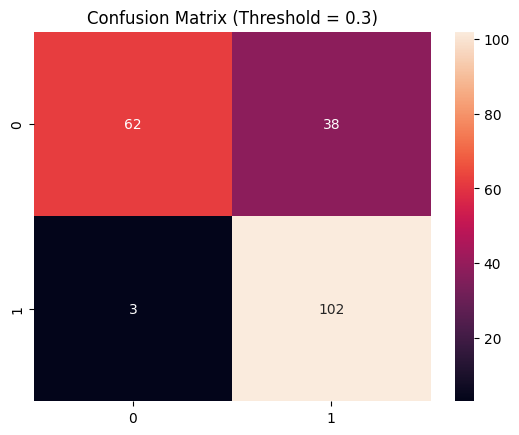

In [38]:
# Manual threshold (domain-based decision)
threshold = 0.3
y_pred_custom = (y_prob >= threshold).astype(int)

print("\n Custom Threshold (0.3) ")
print(classification_report(y_test, y_pred_custom))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred_custom), annot=True, fmt='d')
plt.title("Confusion Matrix (Threshold = 0.3)")
plt.show()



In [39]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_idx = np.argmax(f1_scores)
best_th = thresholds[best_idx]

print(f"Best Threshold (F1 optimal): {best_th:.3f}")
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])

y_pr_opt = (y_prob >= best_th).astype(int)

print("\nDefault Threshold (0.5)")
print(classification_report(y_test, y_pred))

print("\nOptimized Threshold")
print(classification_report(y_test, y_pr_opt))

Best Threshold (F1 optimal): 0.581
Precision: 0.8545454545454545
Recall: 0.8952380952380953

Default Threshold (0.5)
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205


Optimized Threshold
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       100
           1       0.85      0.90      0.87       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



## Precision-Recall Analysis

Precision-Recall curve is also used along with ROC because:
- More informative for medical decision-making.
- Emphasizes on the performance for positive (disease) class.
- The curve shows high precision at low recall, but precision decreases as recall increases, highlighting the trade-off when detecting more positive cases.

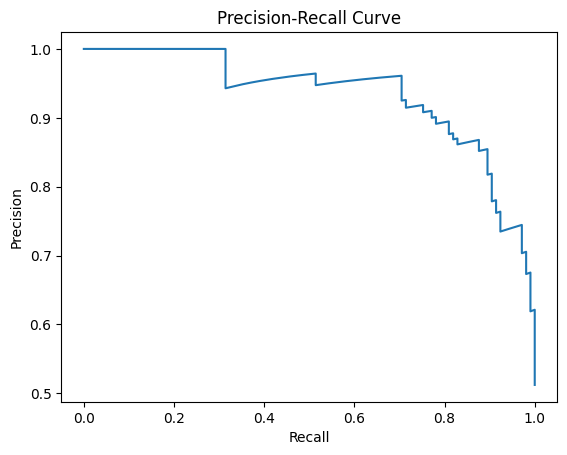

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## Model Calibration

Calibration curve for evaluating how well predicted probabilities reflect actual outcomes.

This is important in healthcare when:
- Reliable probability estimates are required for decision-making.
- Model shows slight deviation from perfect calibration in mid-probability ranges but well-calibrated at extremes.

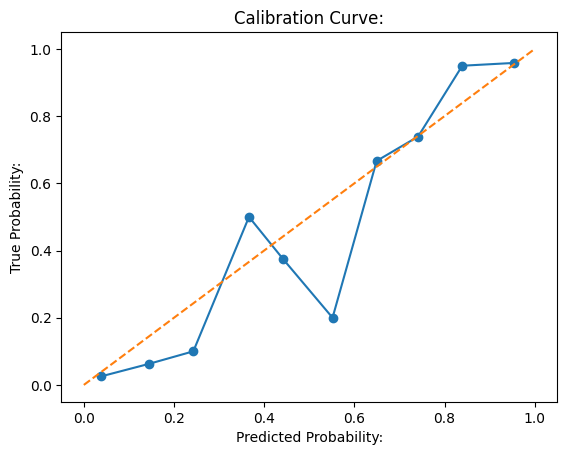

In [41]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability:")
plt.ylabel("True Probability:")
plt.title("Calibration Curve:")
plt.show()

## Model Comparison – Random Forest

Random Forest is used as a comparison model to:
- Capture non-linear relationships.
- Evaluate performance differences with Logistic Regression.

Although Random Forest achieves higher ROC-AUC and recall, Logistic Regression is preferred in clinical settings due to interpretability and transparency.

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


Random Forest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       100
           1       0.98      1.00      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

ROC-AUC: 0.9992380952380953


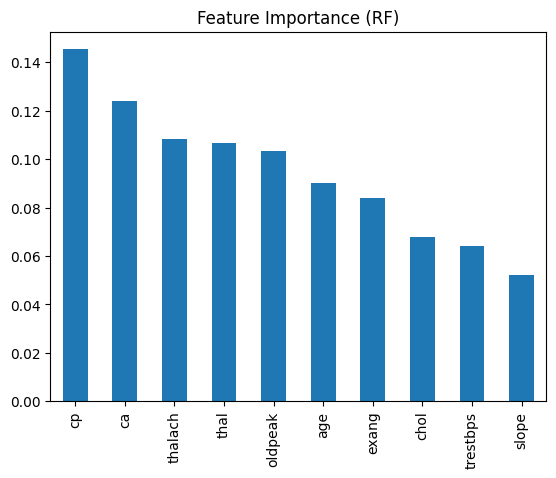

In [43]:
import pandas as pd

importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar', title="Feature Importance (RF)")
plt.show()

## Risk Stratification

Predicted probabilities are categorized into:
- Low Risk
- Medium Risk
- High Risk


Thresholds are data-driven percentile-based to prioritize early detection. Hence making the model, a clinical decision support system.

In [44]:
# Risk Stratification using Random Forest probabilities

low = np.percentile(y_prob, 33)
high = np.percentile(y_prob, 66)

def risk_category(prob):
    if prob < low:
        return "Low Risk"
    elif prob < high:
        return "Medium Risk"
    else:
        return "High Risk"

# Logistic Regression risk 
risk_preds_lr = [risk_category(p) for p in y_prob]

# Random Forest risk
risk_preds_rf = [risk_category(p) for p in y_proba_rf]

print("\nSample Risk Predictions- Logistic Regression:")
print(risk_preds_lr[:10])

print("\nSample Risk Predictions- Random Forest:")
print(risk_preds_rf[:10])

# Compare predictions nicely
comparison_df = pd.DataFrame({
    "Actual": y_test.values[:10],
    "LR_Prob": y_prob[:10],
    "LR_Risk": risk_preds_lr[:10],
    "RF_Prob": y_proba_rf[:10],
    "RF_Risk": risk_preds_rf[:10]
})

print("\nRisk Comparison (First 10 Patients):")
print(comparison_df)


Sample Risk Predictions- Logistic Regression:
['Low Risk', 'Medium Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Low Risk', 'High Risk', 'Medium Risk', 'High Risk', 'Medium Risk']

Sample Risk Predictions- Random Forest:
['Low Risk', 'Medium Risk', 'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'High Risk', 'Low Risk', 'High Risk', 'Medium Risk']

Risk Comparison (First 10 Patients):
   Actual   LR_Prob      LR_Risk   RF_Prob      RF_Risk
0       0  0.023764     Low Risk  0.051072     Low Risk
1       1  0.394607  Medium Risk  0.520909  Medium Risk
2       0  0.018294     Low Risk  0.003290     Low Risk
3       1  0.714198  Medium Risk  0.869261    High Risk
4       0  0.320768     Low Risk  0.062440     Low Risk
5       0  0.037601     Low Risk  0.004001     Low Risk
6       1  0.809756    High Risk  0.791344    High Risk
7       0  0.542110  Medium Risk  0.167810     Low Risk
8       1  0.953851    High Risk  0.984686    High Risk
9       1  0.394607  Medium Risk  0.520909  Mediu

In [45]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

print("Random Forest Cross-Validation ROC-AUC scores:", rf_cv_scores)
print("Mean ROC-AUC:", rf_cv_scores.mean())

Random Forest Cross-Validation ROC-AUC scores: [0.99304762 0.98533333 0.9727619  0.96628571 0.95607014]
Mean ROC-AUC: 0.9746997413487979


## Logistic Regression Coefficients (Feature Influence)

- Logistic Regression coefficients are analyzed for interpretability.
- Top features provide information about the important clinical indicators.
- Positive coefficients increase disease probability, while negative coefficients decrease it.

In [46]:
# Logistic Regression Feature Importance
lr_pipeline.fit(X_train, y_train)

coefficients = lr_pipeline.named_steps['model'].coef_[0]
feature_importance = pd.Series(coefficients, index=X.columns)

print("Logistic Regression Feature Importance")
print(feature_importance.sort_values(ascending=False).head(10))

# Random Forest Feature Importance
rf_importance = pd.Series(best_rf.feature_importances_, index=X.columns)

print("\nRandom Forest Feature Importance")
print(rf_importance.sort_values(ascending=False).head(10))

Logistic Regression Feature Importance
cp          0.864872
thalach     0.416915
slope       0.367618
restecg     0.160736
fbs        -0.014227
age        -0.119903
chol       -0.279509
trestbps   -0.363196
thal       -0.498610
exang      -0.514580
dtype: float64

Random Forest Feature Importance
cp          0.145340
ca          0.123912
thalach     0.108256
thal        0.106809
oldpeak     0.103420
age         0.090238
exang       0.083978
chol        0.067971
trestbps    0.064271
slope       0.052095
dtype: float64


In [47]:
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression report
report_lr = classification_report(y_test, y_pred, output_dict=True)

# Random Forest report
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Create comparison table
res = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_proba_rf)
    ],
    "Recall (Disease)": [
        report_lr['1']['recall'],
        report_rf['1']['recall']
    ],
    "Precision (Disease)": [
        report_lr['1']['precision'],
        report_rf['1']['precision']
    ],
    "F1-Score (Disease)": [
        report_lr['1']['f1-score'],
        report_rf['1']['f1-score']
    ]
})

print("\nModel Comparison:")
print(res.sort_values(by="Recall (Disease)", ascending=False))


Model Comparison:
                 Model   ROC-AUC  Recall (Disease)  Precision (Disease)  \
1        Random Forest  0.999238          1.000000             0.981308   
0  Logistic Regression  0.930667          0.914286             0.761905   

   F1-Score (Disease)  
1            0.990566  
0            0.831169  


Random Forest achieves near-perfect performance on the test set, likely due to dataset size and model complexity, indicating slight overfitting. Cross-validation provides a more reliable estimate.

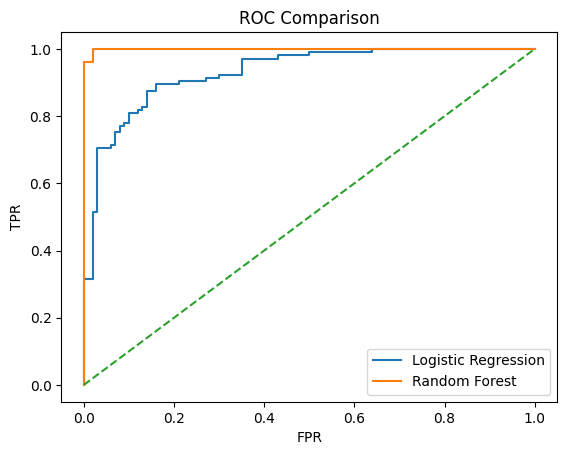

In [48]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Comparison")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

## Key Insights
- Reducing false negatives is critical, as missed diagnoses can lead to severe clinical consequences.
- Logistic Regression provides stable and interpretable predictions.
- Random Forest achieves higher ROC-AUC.
- But Logistic Regression remains more interpretable and reliable for clinical use.
- Threshold optimization to improve the recall while maintaining precision balance.
- Precision-Recall analysis highlights trade-offs in medical settings.
- The calibration curve indicates that predicted probabilities are reasonably aligned with actual outcomes, with minor deviations suggesting slight over/under-confidence in certain probability ranges.
This is important for clinical reliability.

## Limitations
- Dataset is relatively small and it may not generalize to real-world populations.
- Model performance may vary across different demographics.
- Further validation required on larger clinical datasets.
- Model evaluated on single dataset; external validation required.

## Conclusion
This project demonstrates how machine learning can be applied to healthcare with:
- Emphasis on recall for minimizing the missed diagnoses.
- Reliable probability estimation.
- Practical decision-making through risk categorization.

## Future Work
- Hyperparameter tuning using GridSearchCV.
- Testing on larger, real-world clinical datasets.
- Working with more clinical features.

In [49]:
low_sample = X[y == 0].iloc[0]
high_sample = X[y == 1].iloc[0]

import pandas as pd

low_df = pd.DataFrame([low_sample], columns=X.columns)
high_df = pd.DataFrame([high_sample], columns=X.columns)

print("LOW RISK TEST")
print(model.predict(low_df))
print(model.predict_proba(low_df))

print("\nHIGH RISK TEST")
print(model.predict(high_df))
print(model.predict_proba(high_df))

LOW RISK TEST
[0]
[[0.74172235 0.25827765]]

HIGH RISK TEST
[1]
[[0.24092065 0.75907935]]


In [50]:
import joblib

joblib.dump(model, "model.pkl")   # calibrated model
joblib.dump(X.columns.tolist(), "columns.pkl")


print("Saved:", type(model))

Saved: <class 'sklearn.calibration.CalibratedClassifierCV'>


In [51]:
print(df["thal"].unique())
print(df["cp"].unique())
print(df["slope"].unique())
print(df["restecg"].unique())

[3 2 1 0]
[0 1 2 3]
[2 0 1]
[1 0 2]


In [52]:
sample = X.iloc[0:1]
print(best_rf.predict(sample))
print(best_rf.predict_proba(sample))

[0]


[[0.88029227 0.11970773]]


In [53]:
import joblib
print(joblib.load("columns.pkl"))

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [54]:
low = X[y == 0].iloc[0]
print(low)

age          52.0
sex           1.0
cp            0.0
trestbps    125.0
chol        212.0
fbs           0.0
restecg       1.0
thalach     168.0
exang         0.0
oldpeak       1.0
slope         2.0
ca            2.0
thal          3.0
Name: 0, dtype: float64


In [55]:
high = X[y == 1].iloc[0]
print(high)

age          58.0
sex           0.0
cp            0.0
trestbps    100.0
chol        248.0
fbs           0.0
restecg       0.0
thalach     122.0
exang         0.0
oldpeak       1.0
slope         1.0
ca            0.0
thal          2.0
Name: 5, dtype: float64


In [60]:
sample = X.iloc[10]
print(sample)

age          71.0
sex           0.0
cp            0.0
trestbps    112.0
chol        149.0
fbs           0.0
restecg       1.0
thalach     125.0
exang         0.0
oldpeak       1.6
slope         1.0
ca            0.0
thal          2.0
Name: 10, dtype: float64


In [61]:
model.predict(X.iloc[[10]])
model.predict_proba(X.iloc[[10]])

array([[0.21100295, 0.78899705]])

In [62]:
model.predict(X.iloc[[0]])
model.predict_proba(X.iloc[[0]])

array([[0.74172235, 0.25827765]])